In [1]:
%matplotlib inline

import math
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import amjuel
import ehr
import xsection as xs

The ion conversion reaction is included in the basic list of processes used in SOLPS-ITER modeling of the ITER divertor since it is competitive with the other molecular reactions under some conditions.  The rate we use is found in AMJUEL reaction H.3 3.2.3; no other data are needed.  As is described in Kotov's thesis, this rate is actually the result of a model calculation.  Namely, the fundamental data for the process consist of cross sections as a function of the vibrational state of the H$_{2}$ molecule and its "beam" energy (see Juel-4105 by Janev, Reiter and Samm); the key feature is that the process becomes nearly resonant and similar to a charge exchange for vibrational states of $v \geq 4$.  Reiter et al. then compute the H$_{2}$ equilibrium vibrational distribution as a function of the electron temperature and form an ensemble average of the cross sections over that distribution.  The reaction rate then follows by averaging over a Maxwellian distribution for the protons, with the assumption that its temperature is equal to the electron temperature.  AMJUEL offers a single parameter rate with fixed H$_{2}$ "beam" energy of 0.1 eV and a two parameter fit with variable beam energy; we use the latter here since there are no drawbacks to doing so.

Note that the above discussion refers explicitly to H, not D, molecules.  Due to the role of vibrational excitation in the process, the distinction is not trivial as H$_{2}$ and D$_{2}$ vibrational states have different energies.  The only justification for using the same rate for both is found in Steve Lisgo's Ph. D. thesis: the excitation energy for the critical H$_{2}(v = 4)$ and D$_{2}(v = 6)$ states are both about 2 eV.

The other consideration is whether or not the parameters should be scaled by the species mass.  Since the primary dependence of the fundamental cross sections is on the relative velocity, clearly the "beam" energy should be scaled by the mass so that it effectively represents a relative velocity.  Moreover, any drift in the ion distribution function should be included when computing the reaction rate; this is done in the same manner as for charge exchange.  We assume that the temperature dependence is solely the electron temperature since scaling the ion temperature by the mass would result in $T_{e} > T_{i,eff}$ anyway.

So that we can use the same temperature grid as for the other molecular processes, we read in the molecular data file from the collisional radiative model:

In [2]:
h2cr_19_saw = ehr.ehr_data('fort.19')
print(h2cr_19_saw.data_dict.keys())

dict_keys(['  H2 Dissociation Rate(jt,jn) (cm**3 s**-1)  Te(jt) = 10**(-1.2 + (jt-1)/10) jt=1,60\n', '  H2 Dissociative Ionization Rate(jt,jn) (cm**3 s**-1)\n', '  H2+ Dissociative Recombination Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociation Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociative Ionization Rate(jt,jn)  (cm**3 s**-1)\n', '  H2 Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=3 / n=1 (jt,jn)\n', '  H2 Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=2 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=4 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=5 / n=1 (jt,jn)\n', ' H2 Dissociative Excit

In [3]:
ehr19Te = h2cr_19_saw.get_Te()
ehr19ne = h2cr_19_saw.get_ne()
num_Te = ehr19Te.shape[0]
num_ne = ehr19ne.shape[0]

AMJUEL only shows beam energies up to 100 eV.  Tests on that fit showed it failing at $10^{3}$ eV, so we truncate the the list of beam energies at 100 eV.

In [4]:
Eb = ehr19Te[np.where(ehr19Te <= 100.)]
num_Eb = Eb.shape[0]
print(num_Eb)

33


Read the reaction fit coefficients from the AMJUEL file:

In [5]:
amj_file = 'amjuel.tex'

In [6]:
H123 = 'H.3'
reacstr = '3.2.3'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
print(fit_coef)

[[-2.13310498e+01  2.96190590e-01 -2.87689215e-02 -3.32327159e-02
   7.23455834e-03  2.94023010e-04 -8.00503161e-05  0.00000000e+00
   0.00000000e+00]
 [ 2.30846172e+00 -1.06480046e+00  2.31012095e-01  6.80938298e-02
  -4.24121042e-02  8.27115202e-03 -6.27598810e-04  0.00000000e+00
   0.00000000e+00]
 [-2.02615171e+00  1.14280674e+00 -2.62194346e-01 -6.87769443e-02
   4.01271697e-02 -6.14330754e-03  3.23385292e-04  0.00000000e+00
   0.00000000e+00]
 [ 1.64800033e-01 -4.67578650e-01  1.24226191e-01  1.77429486e-02
  -1.15765835e-02  1.31106130e-03 -1.12595773e-05  0.00000000e+00
   0.00000000e+00]
 [ 1.65199358e-01  5.76658469e-02 -3.65992276e-02  7.08334612e-03
   3.40353701e-04 -2.75215279e-04  2.22516585e-05  0.00000000e+00
   0.00000000e+00]
 [-2.59845807e-02  1.34914435e-02  8.87165980e-03 -5.23116204e-03
   3.32424165e-04  1.98558566e-04 -2.81363085e-05  0.00000000e+00
   0.00000000e+00]
 [-4.33045351e-03 -5.24640434e-03 -1.63610718e-03  1.24202315e-03
  -4.52477463e-05 -6.3694157

And evaluate the fit:

In [7]:
data_232 = np.zeros((num_Eb,num_Te))
for jt in range(num_Te):
    for je in range(num_Eb):
        data_232[je,jt] = amjuel.Eb_T_exp_fit(fit_coef,Eb[je],ehr19Te[jt])

In [8]:
print(Eb)

[6.30957344e-02 7.94328235e-02 1.00000000e-01 1.25892541e-01
 1.58489319e-01 1.99526231e-01 2.51188643e-01 3.16227766e-01
 3.98107171e-01 5.01187234e-01 6.30957344e-01 7.94328235e-01
 1.00000000e+00 1.25892541e+00 1.58489319e+00 1.99526231e+00
 2.51188643e+00 3.16227766e+00 3.98107171e+00 5.01187234e+00
 6.30957344e+00 7.94328235e+00 1.00000000e+01 1.25892541e+01
 1.58489319e+01 1.99526231e+01 2.51188643e+01 3.16227766e+01
 3.98107171e+01 5.01187234e+01 6.30957344e+01 7.94328235e+01
 1.00000000e+02]


Plot first as a function of $T_{e}$:

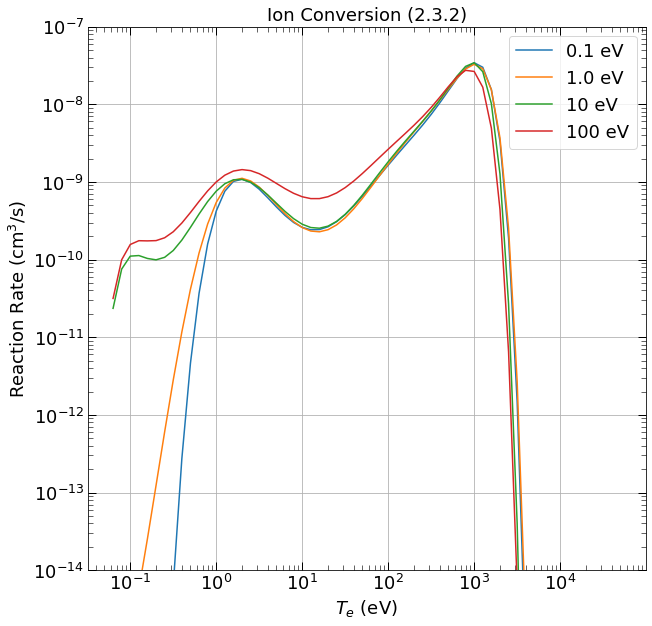

In [9]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,data_232[2,:],label='0.1 eV')
plt.plot(ehr19Te,data_232[12,:],label='1.0 eV')
plt.plot(ehr19Te,data_232[22,:],label='10 eV')
plt.plot(ehr19Te,data_232[32,:],label='100 eV')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_ylim((1.e-14,1.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('Ion Conversion (2.3.2)',fontsize=18)
plt.legend(fontsize=18)

And as a function of beam energy, $E_{b}$:

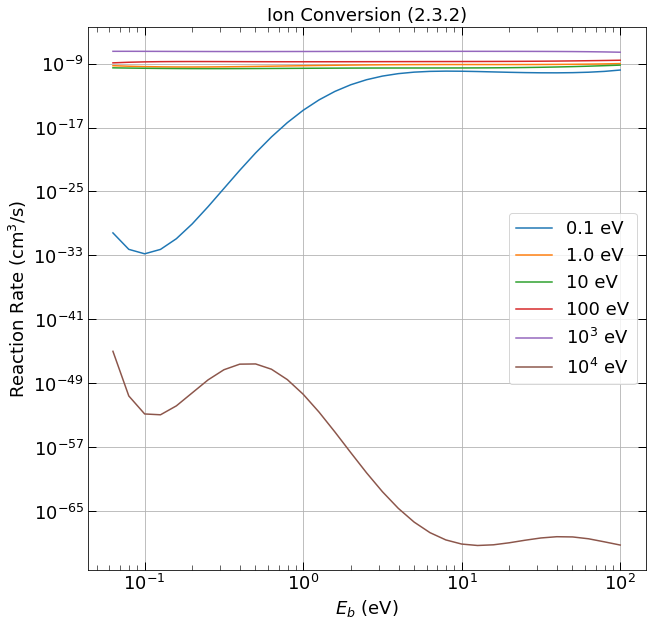

In [10]:
plt.figure(figsize=(10,10))
plt.plot(Eb,data_232[:,2],label='0.1 eV')
plt.plot(Eb,data_232[:,12],label='1.0 eV')
plt.plot(Eb,data_232[:,22],label='10 eV')
plt.plot(Eb,data_232[:,32],label='100 eV')
plt.plot(Eb,data_232[:,42],label='$10^{3}$ eV')
plt.plot(Eb,data_232[:,52],label='$10^{4}$ eV')
plt.xlabel('$E_{b}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_ylim((1.e-14,1.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('Ion Conversion (2.3.2)',fontsize=18)
plt.legend(fontsize=18)

Writing the data to the netCDF file consists of two steps.  The first involves defining the independent and dependent variables and then setting up the data table that holds all of the actual rate data.

The variables being written to this file are: 

0. Reaction rate(temperature,specific energy)

As above, there are num_Eb energy values and num_Te temperature values.   Note that we change from using (energy,temperature)  in these notebooks to (temperature,energy) in the netCDF file.  The latter is to be consistent with the convention in the H CR files, such as hionize5.nc, in which the dominant temperature dependence is easy to see in the file.  The swap is effected by sending the transpose of the data arrays in the set_data method calls below.  

This initialization call sets the name of the reaction and the netCDF file, and specifies the number of dependent variables.

In [11]:
h2ion_conv = xs.xs_data('h2ion_conv',1)

Now, provide the name, evaluation name (not really used), dimensions, units, multiplier, independent variable minimum and maximum, and the spacing method used for interpolation for this one dependent variable.

Note that we use the "specific energy" independent variable, which is evaluated in the code as $0.5 v_{rel}^{2}$.  To get that from the H$_{2}$ energy values used here, we need to divide out the H$_{2}$ mass, which is roughly 2 AMU.

In [12]:
h2ion_conv.set_var(0,['reaction_rate','elec_temperature','specific_energy'],'table',
              [num_Te,num_Eb],['cm^3/s','eV','eV/amu'],
              [1.e-6,xs.electron_charge,xs.electron_charge/(2.*xs.atomic_mass_unit)],
              [ehr19Te[0],Eb[0]],
              [ehr19Te[-1],Eb[-1]],
              ['log']*3)

Fill in the data table.  Some of the array values are $< 10^{-100}$, so we follow the standard practice used in other data files of enforcing a minimum value of $10^{-99}$.

In [13]:
h2ion_conv.set_data(0,np.fmax(data_232,1.e-99).T)   # Note the transpose; see above.

Now open the netCDF file, write in the data using the h2ion_conv xs_data data structures, and close the file.

In [14]:
work_dir = './'
h2ion_conv_nc = xs.xs_netCDF.write_ncfile(h2ion_conv,work_dir,
                        'Reference atomic physics data for a reaction in degas 2',
                        'V. 1.0, H2 ion conversion')
h2ion_conv_nc.close()